In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [2]:
wild = pd.read_csv('../hpai_wild_janmay25.csv')
# lbm = pd.read_csv('../hpai_lbm_janmay25.csv')
# com = pd.read_csv('../hpai_commercial_janmay25.csv')
wild

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency
0,South Carolina,Chester,5/20/2025,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
1,South Carolina,Chester,5/20/2025,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
2,South Carolina,Chester,5/20/2025,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
3,South Carolina,Chester,5/20/2025,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
4,South Carolina,Chester,5/20/2025,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
...,...,...,...,...,...,...,...,...,...
1018,Idaho,Gooding,1/2/2025,1/16/2025,EA H5,Mallard,Wild bird,Hunter harvest,NWDP
1019,Iowa,Cherokee,1/2/2025,1/16/2025,EA/AM H5N1,Canada goose,Wild bird,Morbidity/Mortality,USDA Wildlife Services
1020,Alabama,Limestone,1/2/2025,1/16/2025,EA/AM H5N1,Snow goose,Wild bird,Hunter harvest,NWDP
1021,Utah,Box Elder,1/2/2025,1/16/2025,EA H5,American wigeon,Wild bird,Hunter harvest,NWDP


In [5]:
pa_wild = pd.read_csv('../../sample_data/hpai-wild-birds-all-detections.csv')
pa_wild['Collection Date'] = pd.to_datetime(pa_wild['Collection Date'], errors='coerce').dt.strftime('%Y-%m-%d')
pa_wild = pa_wild[(pa_wild['State'] == 'Pennsylvania')]
pa_wild

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency
82,Pennsylvania,Philadelphia,2026-03-31,4/14/2026,EA H5,Bald eagle,Wild bird,Morbidity/Mortality,PA Game Commission
251,Pennsylvania,Columbia,2026-03-18,3/31/2026,EA/AM H5N1,Red-tailed hawk,Wild bird,Morbidity/Mortality,PA Game Commission
280,Pennsylvania,Bucks,2026-02-19,3/26/2026,EA/AM H5N1,Canada goose,Wild bird,Morbidity/Mortality,PA Game Commission
281,Pennsylvania,Warren,2026-03-06,3/26/2026,EA/AM H5N1,Common raven,Wild bird,Morbidity/Mortality,PA Game Commission
282,Pennsylvania,Bucks,2026-03-16,3/26/2026,EA H5,Common merganser,Wild bird,Morbidity/Mortality,PA Game Commission
...,...,...,...,...,...,...,...,...,...
18880,Pennsylvania,Venango,2022-03-21,3/28/2022,EA H5N1,Merganser (unidentified),Wild bird,Morbidity/Mortality,PA Game Commission
18881,Pennsylvania,Venango,2022-03-21,3/28/2022,EA H5N1,Merganser (unidentified),Wild bird,Morbidity/Mortality,PA Game Commission
18882,Pennsylvania,Venango,2022-03-21,3/28/2022,EA H5N1,Merganser (unidentified),Wild bird,Morbidity/Mortality,PA Game Commission
18883,Pennsylvania,Venango,2022-03-21,3/28/2022,EA H5N1,Merganser (unidentified),Wild bird,Morbidity/Mortality,PA Game Commission


In [22]:
pa_comm = pd.read_csv('../../sample_data/hpai-comm-birds-all-detections.csv')
pa_comm['Confirmed Diagnosis'] = pd.to_datetime(pa_comm['Confirmed Diagnosis'], format='%d-%b-%y')
pa_comm = pa_comm[(pa_comm['State'] == 'Pennsylvania')]
pa_comm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133 entries, 19 to 2163
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Special ID             133 non-null    object        
 1   County Name            133 non-null    object        
 2   State                  133 non-null    object        
 3   Production             133 non-null    object        
 4   Confirmed Diagnosis    133 non-null    datetime64[ns]
 5   Control Area Released  116 non-null    object        
 6   Unnamed: 6             133 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 8.3+ KB


In [75]:
pa_comm['Production'].unique()

array(['WOAH Poultry', 'Commercial Duck Meat Bird',
       'Commercial Table Egg Layer', 'Commercial Broiler Production',
       'Commercial Turkey Meat Bird', 'Commercial Table Egg Pullets',
       'Live Bird Market', 'WOAH Non-Poultry',
       'Commercial Raised for Release Upland Game Bird',
       'Commercial Duck Breeder', 'Commercial Turkey Breeder Toms',
       'Commercial Turkey Breeder Hens', 'Commercial Table Egg Breeder',
       'Commercial Broiler Breeder Pullets'], dtype=object)

In [76]:
pa_comm_nolbm = pa_comm[(pa_comm['Production'] != 'Live Bird Market')]
pa_lbm = pa_comm[(pa_comm['Production'] == 'Live Bird Market')]


In [3]:
wild['Collection Date'] = pd.to_datetime(wild['Collection Date'], errors='coerce').dt.strftime('%Y-%m-%d')
wild

,State,County,Collection Date,Date Detected,HPAI Strain,Bird Species,WOAH Classification,Sampling Method,Submitting Agency
0,South Carolina,Chester,2025-05-20,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
1,South Carolina,Chester,2025-05-20,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
2,South Carolina,Chester,2025-05-20,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
3,South Carolina,Chester,2025-05-20,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
4,South Carolina,Chester,2025-05-20,5/30/2025,EA/AM H5N1,Black vulture,Wild bird,Morbidity/Mortality,NWDP
...,...,...,...,...,...,...,...,...,...
1018,Idaho,Gooding,2025-01-02,1/16/2025,EA H5,Mallard,Wild bird,Hunter harvest,NWDP
1019,Iowa,Cherokee,2025-01-02,1/16/2025,EA/AM H5N1,Canada goose,Wild bird,Morbidity/Mortality,USDA Wildlife Services
1020,Alabama,Limestone,2025-01-02,1/16/2025,EA/AM H5N1,Snow goose,Wild bird,Hunter harvest,NWDP
1021,Utah,Box Elder,2025-01-02,1/16/2025,EA H5,American wigeon,Wild bird,Hunter harvest,NWDP


In [4]:
wild = wild[(wild['Collection Date'] >= '2025-01-01') & (wild['Collection Date'] <= '2025-06-01')]

wild['Collection Date'].min()

'2025-01-02'

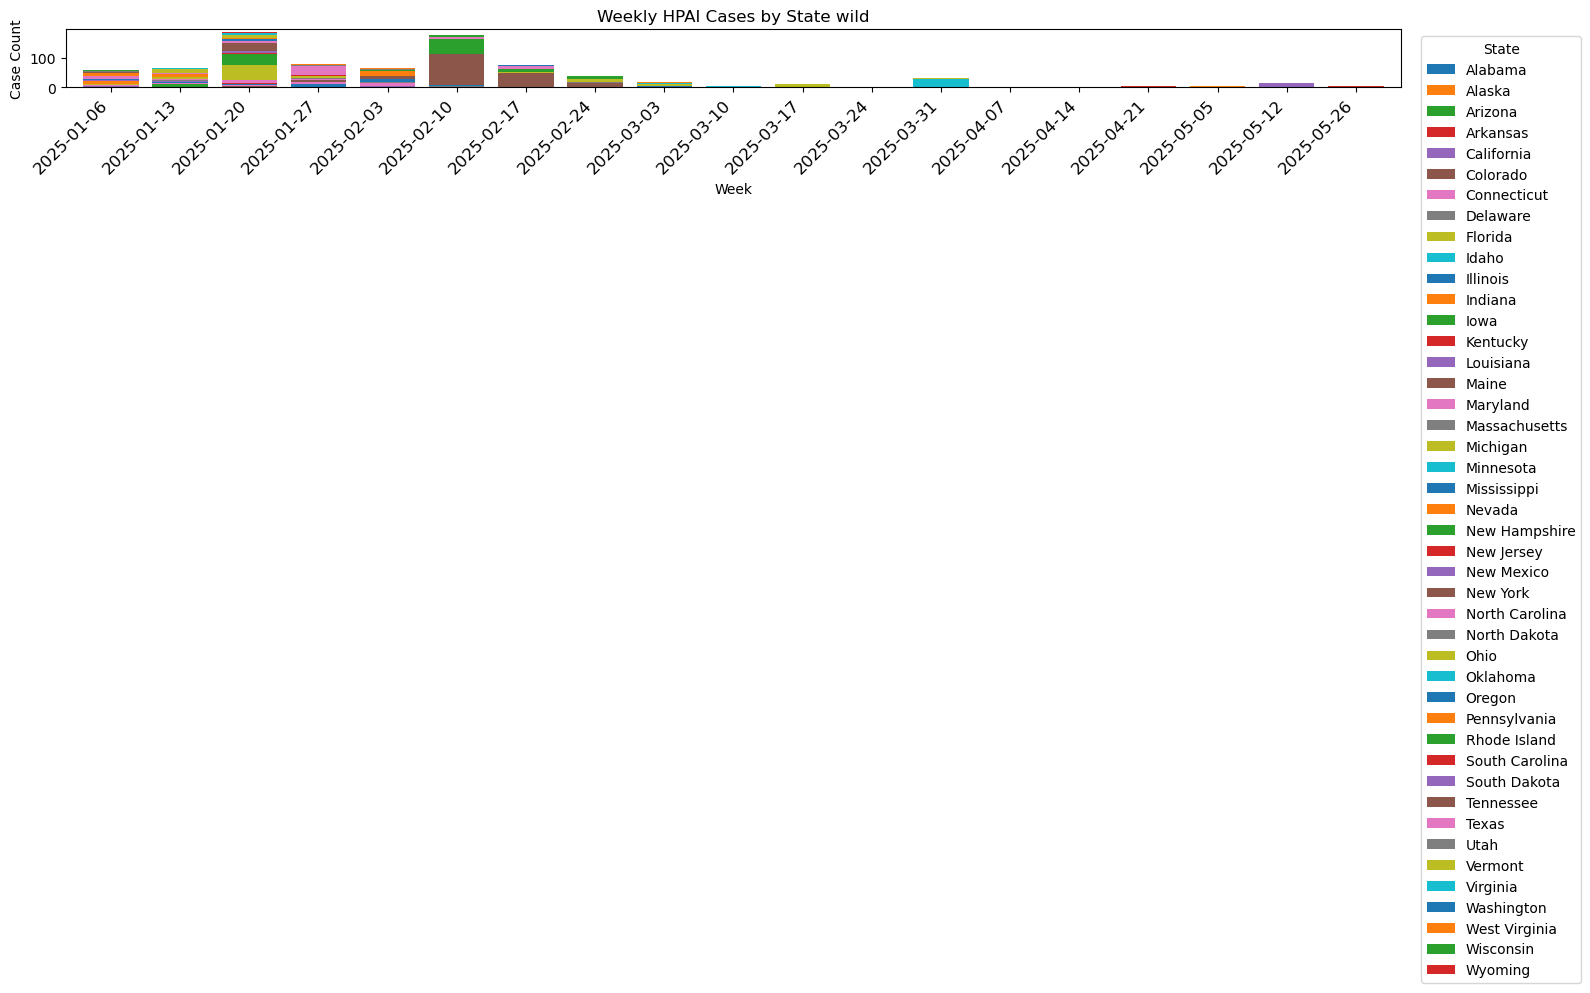

In [75]:
# Group by state and week
wild['Collection Date'] = pd.to_datetime(wild['Collection Date'], errors='coerce')

weekly = (
    wild.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

# Pivot so each state is a column (needed for stacked bar)
weekly_pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

weekly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8
)

# Convert numeric bar positions back to date labels
week_dates = weekly_pivot.index
ax.set_xticks(range(len(week_dates)))
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in week_dates], rotation=45, ha='right', fontsize=12)

ax.set_xlabel('Week')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State wild')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

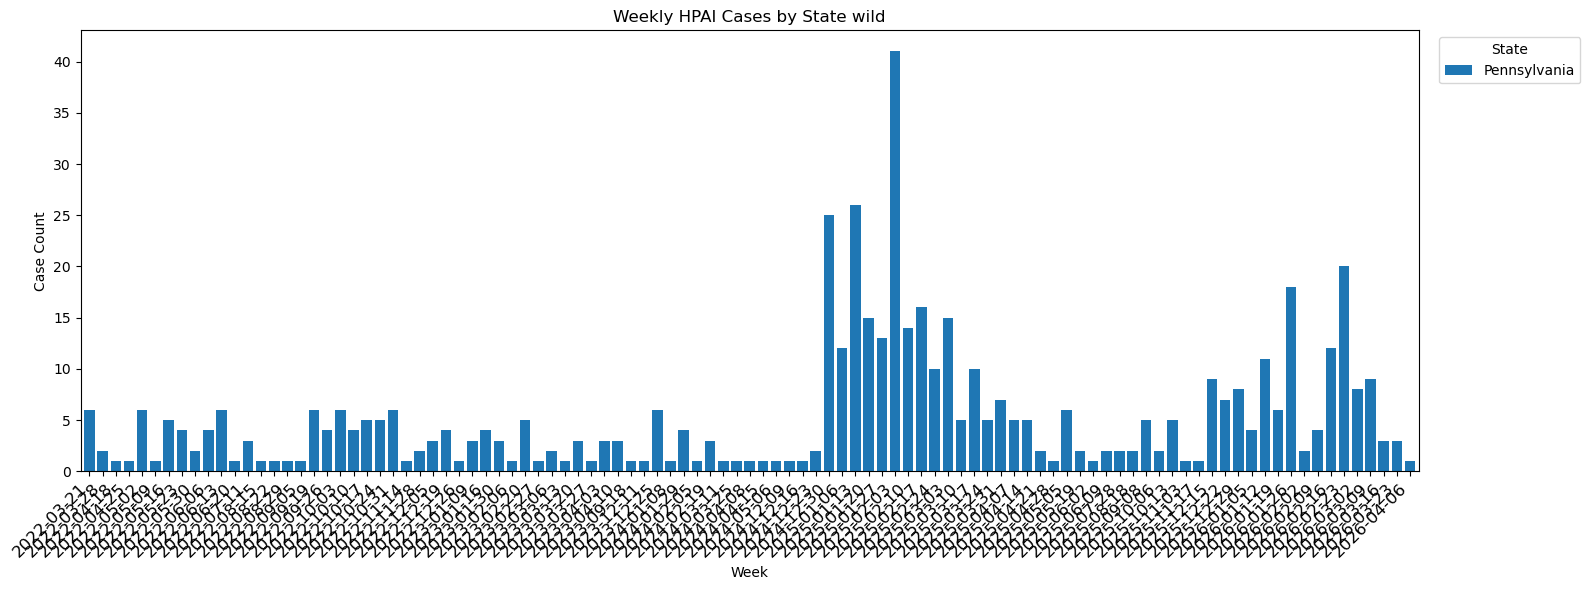

In [10]:
# Group by state and week
pa_wild['Collection Date'] = pd.to_datetime(pa_wild['Collection Date'], errors='coerce')

weekly = (
    pa_wild.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

# Pivot so each state is a column (needed for stacked bar)
weekly_pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

weekly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8
)

# Convert numeric bar positions back to date labels
week_dates = weekly_pivot.index
ax.set_xticks(range(len(week_dates)))
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in week_dates], rotation=45, ha='right', fontsize=12)


ax.set_xlabel('Week')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State wild')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

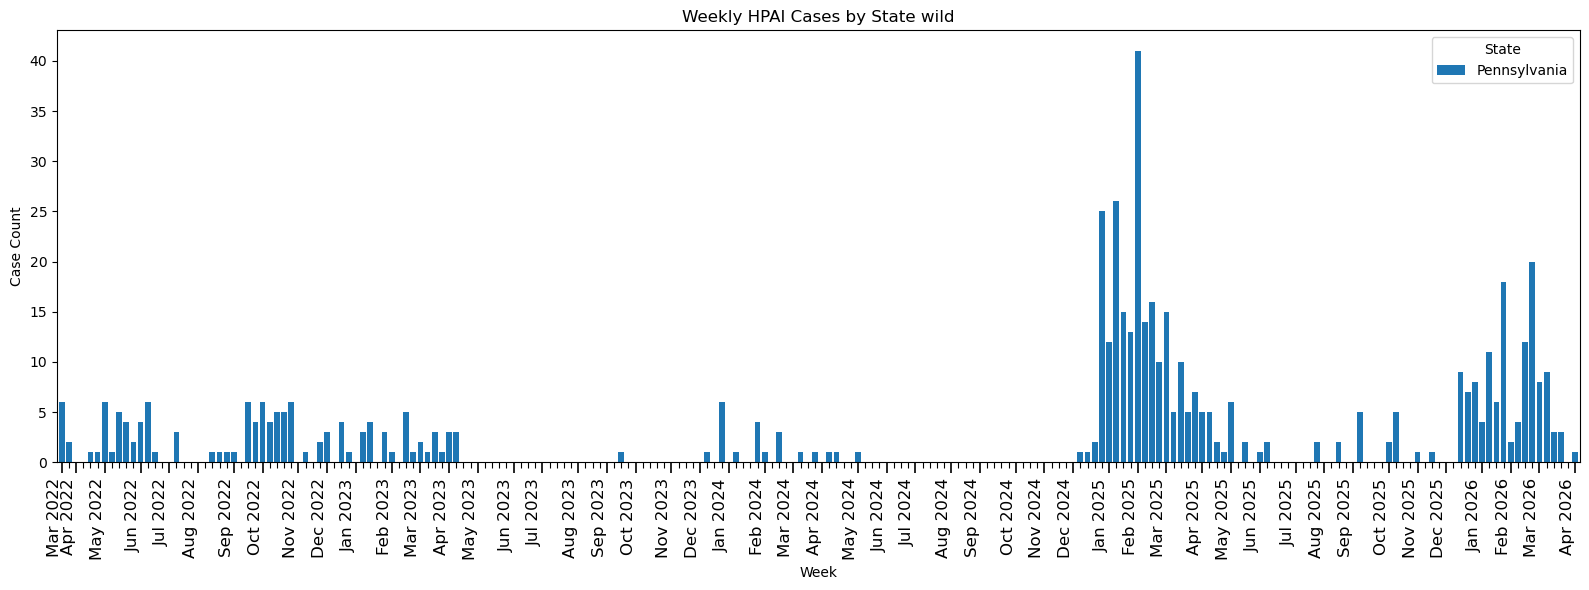

In [17]:
fig, ax = plt.subplots(figsize=(16, 6))


##add in weeks with no cases

pa_wild['Collection Date'] = pd.to_datetime(pa_wild['Collection Date'], errors='coerce')
weekly = (
    pa_wild.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)
weekly_pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)

# --- Fill in missing weeks ---
full_range = pd.date_range(
    start=weekly_pivot.index.min(),
    end=weekly_pivot.index.max(),
    freq='W-MON'
)
weekly_pivot = weekly_pivot.reindex(full_range, fill_value=0)


weekly_pivot.plot(kind='bar', stacked=True, ax=ax, width=0.8)

week_dates = weekly_pivot.index



# --- Major ticks: first week of each month ---
major_positions = []
major_labels = []
seen_months = set()

for i, d in enumerate(week_dates):
    month_key = (d.year, d.month)
    if month_key not in seen_months:
        seen_months.add(month_key)
        major_positions.append(i)
        major_labels.append(d.strftime('%b %Y'))

ax.set_xticks(major_positions)
ax.set_xticklabels(major_labels, rotation=90, ha='right', fontsize=12)

# --- Minor ticks: every week, no label ---
ax.set_xticks(range(len(week_dates)), minor=True)
ax.set_xticklabels([], minor=True)

# --- Tick styling ---
ax.tick_params(axis='x', which='major', length=8, width=1.2)
ax.tick_params(axis='x', which='minor', length=4, width=0.8)

ax.set_xlabel('Week')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State wild')
# ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

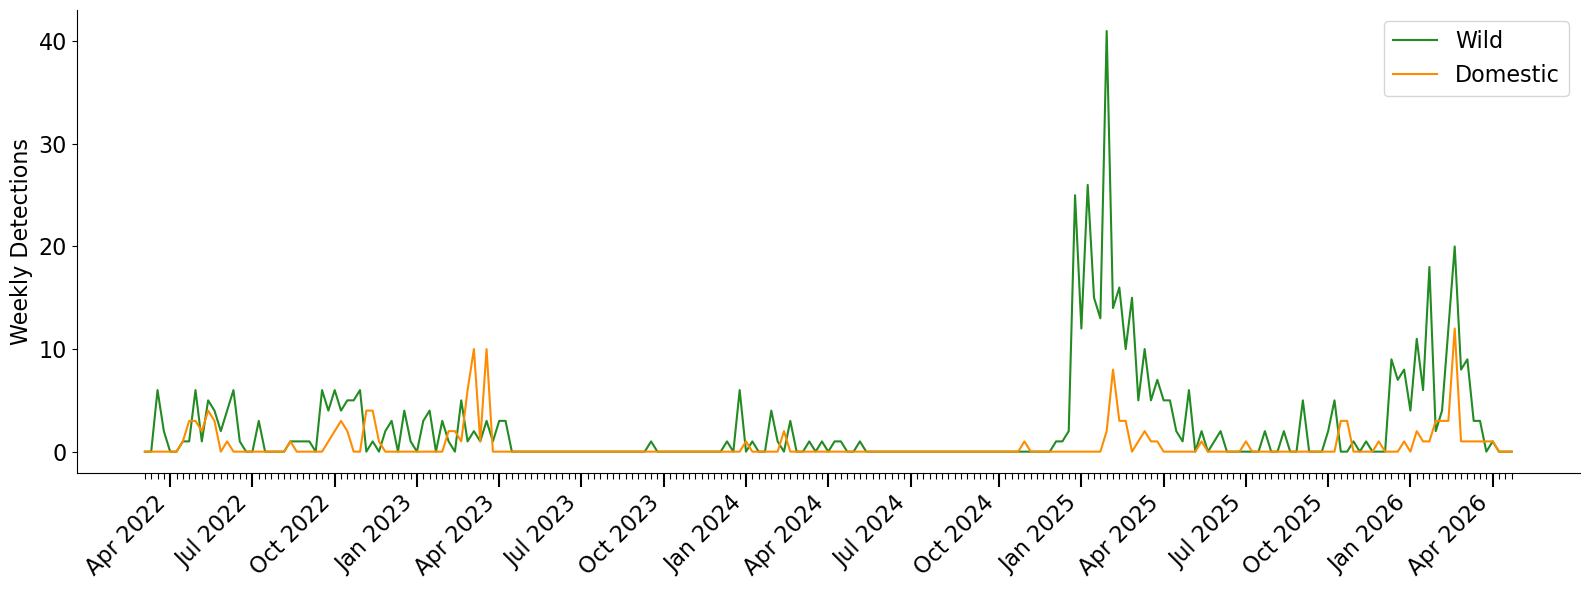

In [53]:
pa_wild['Collection Date'] = pd.to_datetime(pa_wild['Collection Date'], errors='coerce')
# pa_comm['Confirmed Diagnosis'] = pd.to_datetime(pa_comm['Confirmed Diagnosis'], errors='coerce')
pa_comm.rename(columns={"Confirmed Diagnosis": "Collection Date"}, inplace=True)

def make_weekly_pivot(df):
    weekly = (
        df.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
        .size()
        .reset_index(name='cases')
    )
    pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)
    full_range = pd.date_range(
        start=min(wild_pivot.index.min(), comm_pivot.index.min()).replace(day=1),
        end=max(wild_pivot.index.max(), comm_pivot.index.max()) + pd.offsets.MonthEnd(1),
        freq='W-MON'
    )
    return pivot.reindex(full_range, fill_value=0)

wild_pivot = make_weekly_pivot(pa_wild)
comm_pivot = make_weekly_pivot(pa_comm)

# Align both to the same full date range
full_range = pd.date_range(
    start=min(wild_pivot.index.min(), comm_pivot.index.min()),
    end=max(wild_pivot.index.max(), comm_pivot.index.max()),
    freq='W-MON'
)
wild_pivot = wild_pivot.reindex(full_range, fill_value=0)
comm_pivot = comm_pivot.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))


# ax.bar(range(len(full_range)), wild_pivot.sum(axis=1).values,
#        width=0.8, color='forestgreen', label='Wild')

# ax.bar(range(len(full_range)), comm_pivot.sum(axis=1).values,
#        bottom=wild_pivot.sum(axis=1).values,
#        width=0.8, color='darkorange', label='Commercial')

##change to line plot
ax.plot(range(len(full_range)), wild_pivot.sum(axis=1).values, color='forestgreen', label='Wild')

ax.plot(range(len(full_range)), comm_pivot.sum(axis=1).values, color='darkorange', label='Domestic')


# --- Ticks ---
# major_positions, major_labels = [], []
# seen_months = set()
# for i, d in enumerate(full_range):
#     month_key = (d.year, d.month)
#     if month_key not in seen_months:
#         seen_months.add(month_key)
#         major_positions.append(i)
#         major_labels.append(d.strftime('%b %Y'))


##quarterly month labels
major_positions, major_labels = [], []
seen_months = set()
for i, d in enumerate(full_range):
    month_key = (d.year, d.month)
    if month_key not in seen_months and d.month in {1, 4, 7, 10}:
        seen_months.add(month_key)
        major_positions.append(i)
        major_labels.append(d.strftime('%b %Y'))


ax.set_xticks(major_positions)
ax.set_xticklabels(major_labels, rotation=45, ha='right', fontsize=16)
# ax.set_yticklabels(,fontsize=16)

ax.set_xticks(range(len(full_range)), minor=True)
ax.set_xticklabels([], minor=True)
ax.tick_params(axis='x', which='major', length=10, width=1.5)
ax.tick_params(axis='x', which='minor', length=4, width=0.8)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_xlabel('')
ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel('Weekly Detections', fontsize=16)
# ax.set_title('Weekly HPAI Cases — Wild and Commercial')
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

In [69]:
comm_pivot.to_csv('../comm-pa/output_dfs/comm_pivot.csv')
wild_pivot.to_csv('../comm-pa/output_dfs/wild_pivot.csv')


In [77]:
pa_comm_nolbm.info()

<class 'pandas.core.frame.DataFrame'>
Index: 126 entries, 19 to 2163
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Special ID             126 non-null    object        
 1   County Name            126 non-null    object        
 2   State                  126 non-null    object        
 3   Production             126 non-null    object        
 4   Collection Date        126 non-null    datetime64[ns]
 5   Control Area Released  116 non-null    object        
 6   Unnamed: 6             126 non-null    object        
dtypes: datetime64[ns](1), object(6)
memory usage: 7.9+ KB


In [82]:
pa_comm_nolbm.to_csv('../comm-pa/output_dfs/pa_comm_nolbm.csv')
pa_wild.to_csv('../comm-pa/output_dfs/pa_wild.csv')
pa_lbm.to_csv('../comm-pa/output_dfs/pa_lbm.csv')

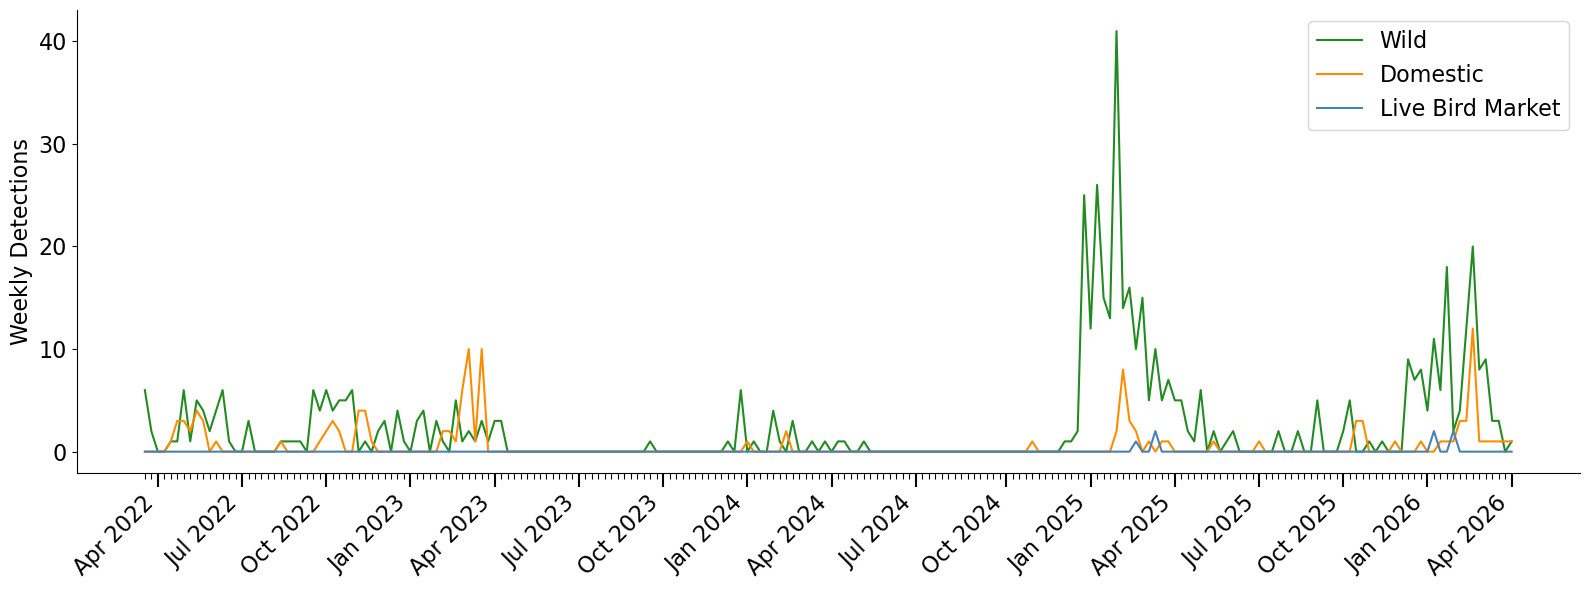

In [80]:
###making version with comm split up to lbm and comm(no lbm)
def make_weekly_pivot(df):
    weekly = (
        df.groupby(['State', pd.Grouper(key='Collection Date', freq='W-MON')])
        .size()
        .reset_index(name='cases')
    )
    pivot = weekly.pivot_table(index='Collection Date', columns='State', values='cases', fill_value=0)
    return pivot

wild_pivot = make_weekly_pivot(pa_wild)
comm_pivot = make_weekly_pivot(pa_comm_nolbm)
lbm_pivot  = make_weekly_pivot(pa_lbm)

# Align all three to the same full date range
full_range = pd.date_range(
    start=min(wild_pivot.index.min(), comm_pivot.index.min(), lbm_pivot.index.min()),
    end=max(wild_pivot.index.max(), comm_pivot.index.max(), lbm_pivot.index.max()),
    freq='W-MON'
)
wild_pivot = wild_pivot.reindex(full_range, fill_value=0)
comm_pivot = comm_pivot.reindex(full_range, fill_value=0)
lbm_pivot  = lbm_pivot.reindex(full_range, fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(range(len(full_range)), wild_pivot.sum(axis=1).values, color='forestgreen', label='Wild')
ax.plot(range(len(full_range)), comm_pivot.sum(axis=1).values, color='darkorange',  label='Domestic')
ax.plot(range(len(full_range)), lbm_pivot.sum(axis=1).values,  color='steelblue',   label='Live Bird Market')

# --- Quarterly x-axis ticks ---
major_positions, major_labels = [], []
seen_months = set()
for i, d in enumerate(full_range):
    month_key = (d.year, d.month)
    if month_key not in seen_months and d.month in {1, 4, 7, 10}:
        seen_months.add(month_key)
        major_positions.append(i)
        major_labels.append(d.strftime('%b %Y'))

ax.set_xticks(major_positions)
ax.set_xticklabels(major_labels, rotation=45, ha='right', fontsize=16)
ax.set_xticks(range(len(full_range)), minor=True)
ax.set_xticklabels([], minor=True)
ax.tick_params(axis='x', which='major', length=10, width=1.5)
ax.tick_params(axis='x', which='minor', length=4, width=0.8)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.tick_params(axis='y', labelsize=16)
ax.set_ylabel('Weekly Detections', fontsize=16)
ax.legend(fontsize=16)
plt.tight_layout()
plt.show()

In [79]:
comm_pivot.to_csv('../comm-pa/output_dfs/comm_nolbm_pivot.csv')
lbm_pivot.to_csv('../comm-pa/output_dfs/lbm_pivot.csv')

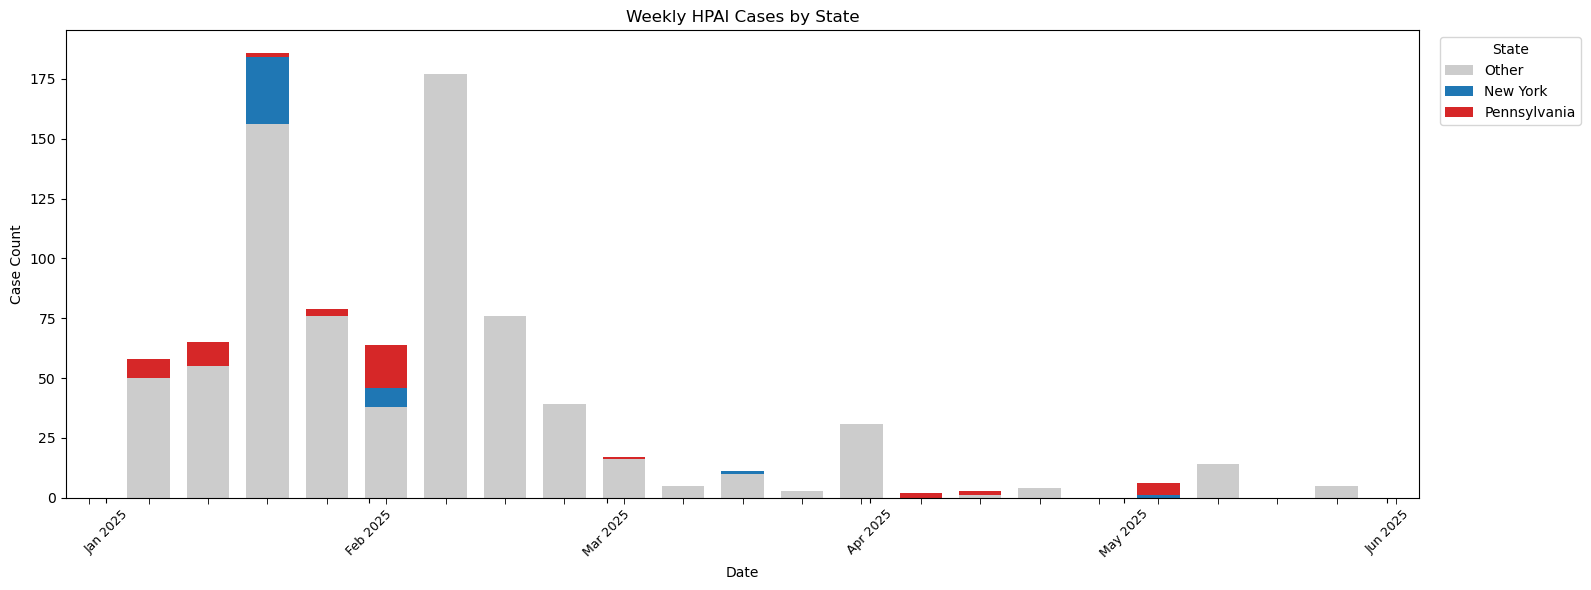

In [77]:
# Remap states to NY, PA, and Other
state_map = {s: s if s in ['New York', 'Pennsylvania'] else 'Other' for s in wild['State'].unique()}
wild['state_grouped'] = wild['State'].map(state_map)

# Group by remapped state and week
weekly = (
    wild.groupby(['state_grouped', pd.Grouper(key='Collection Date', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Collection Date', columns='state_grouped', values='cases', fill_value=0)

# Ensure consistent column order
col_order = [c for c in ['Other', 'New York', 'Pennsylvania'] if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# --- Plot ---
colors = {'Other': '#cccccc', 'New York': '#1f77b4', 'Pennsylvania': '#d62728'}

fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

for state in col_order:
    ax.bar(x, weekly_pivot[state], width=width,
           bottom=bottoms, label=state, color=colors[state])
    bottoms += weekly_pivot[state].values

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=9, rotation=45)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('Date')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State, wild')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [71]:
com_lbm = pd.read_csv('../hpai_comm_lbm_janmay25.tsv', sep='\t')
com_lbm

,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6
0,Maricopa 04,Maricopa,Arizona,Commercial Table Egg Layer,30-May-25,17-Jul-25,"1,354,200"
1,Essex 02,Essex,New Jersey,Live Bird Market,27-May-25,NaN,120
2,Maricopa 03,Maricopa,Arizona,Commercial Table Egg Layer,27-May-25,23-Jul-25,"1,552,000"
3,Maricopa 02,Maricopa,Arizona,Commercial Table Egg Layer,19-May-25,29-Jun-25,"2,258,100"
4,Northampton 02,Northampton,Pennsylvania,WOAH Non-Poultry,19-May-25,NaN,30
...,...,...,...,...,...,...,...
324,Canyon 17,Canyon,Idaho,WOAH Non-Poultry,03-Jan-25,NaN,20
325,Pocahontas 01,Pocahontas,West Virginia,WOAH Poultry,03-Jan-25,17-Jan-25,9
326,Sharp 01,Sharp,Arkansas,WOAH Non-Poultry,03-Jan-25,NaN,20
327,Stanislaus 17,Stanislaus,California,Commercial Broiler Production,03-Jan-25,15-Feb-25,"236,100"


In [34]:
lbm = com_lbm[com_lbm['Production'] =='Live Bird Market']
lbm

,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6
1,Essex 02,Essex,New Jersey,Live Bird Market,27-May-25,NaN,120
6,Essex 01,Essex,New Jersey,Live Bird Market,12-May-25,NaN,"1,400"
8,Miami-Dade 11,Miami-dade,Florida,Live Bird Market,08-May-25,NaN,280
13,Queens 18,Queens,New York,Live Bird Market,24-Apr-25,NaN,0
16,Queens 17,Queens,New York,Live Bird Market,18-Apr-25,NaN,930
18,Queens 16,Queens,New York,Live Bird Market,14-Apr-25,NaN,390
21,Queens 15,Queens,New York,Live Bird Market,11-Apr-25,NaN,240
24,Queens 14,Queens,New York,Live Bird Market,08-Apr-25,NaN,0
26,Queens 13,Queens,New York,Live Bird Market,07-Apr-25,NaN,300
29,Queens 12,Queens,New York,Live Bird Market,02-Apr-25,NaN,40


In [35]:
lbm['Confirmed Diagnosis'] = pd.to_datetime(lbm['Confirmed Diagnosis'], format='%d-%b-%y')

# weekly_lbm = lbm.groupby(pd.Grouper(key='Confirmed Diagnosis', freq='W-MON', closed='left', label='left'))
lbm

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_33081/2840480372.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lbm['Confirmed Diagnosis'] = pd.to_datetime(lbm['Confirmed Diagnosis'], format='%d-%b-%y')


,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6
1,Essex 02,Essex,New Jersey,Live Bird Market,2025-05-27,NaN,120
6,Essex 01,Essex,New Jersey,Live Bird Market,2025-05-12,NaN,"1,400"
8,Miami-Dade 11,Miami-dade,Florida,Live Bird Market,2025-05-08,NaN,280
13,Queens 18,Queens,New York,Live Bird Market,2025-04-24,NaN,0
16,Queens 17,Queens,New York,Live Bird Market,2025-04-18,NaN,930
18,Queens 16,Queens,New York,Live Bird Market,2025-04-14,NaN,390
21,Queens 15,Queens,New York,Live Bird Market,2025-04-11,NaN,240
24,Queens 14,Queens,New York,Live Bird Market,2025-04-08,NaN,0
26,Queens 13,Queens,New York,Live Bird Market,2025-04-07,NaN,300
29,Queens 12,Queens,New York,Live Bird Market,2025-04-02,NaN,40


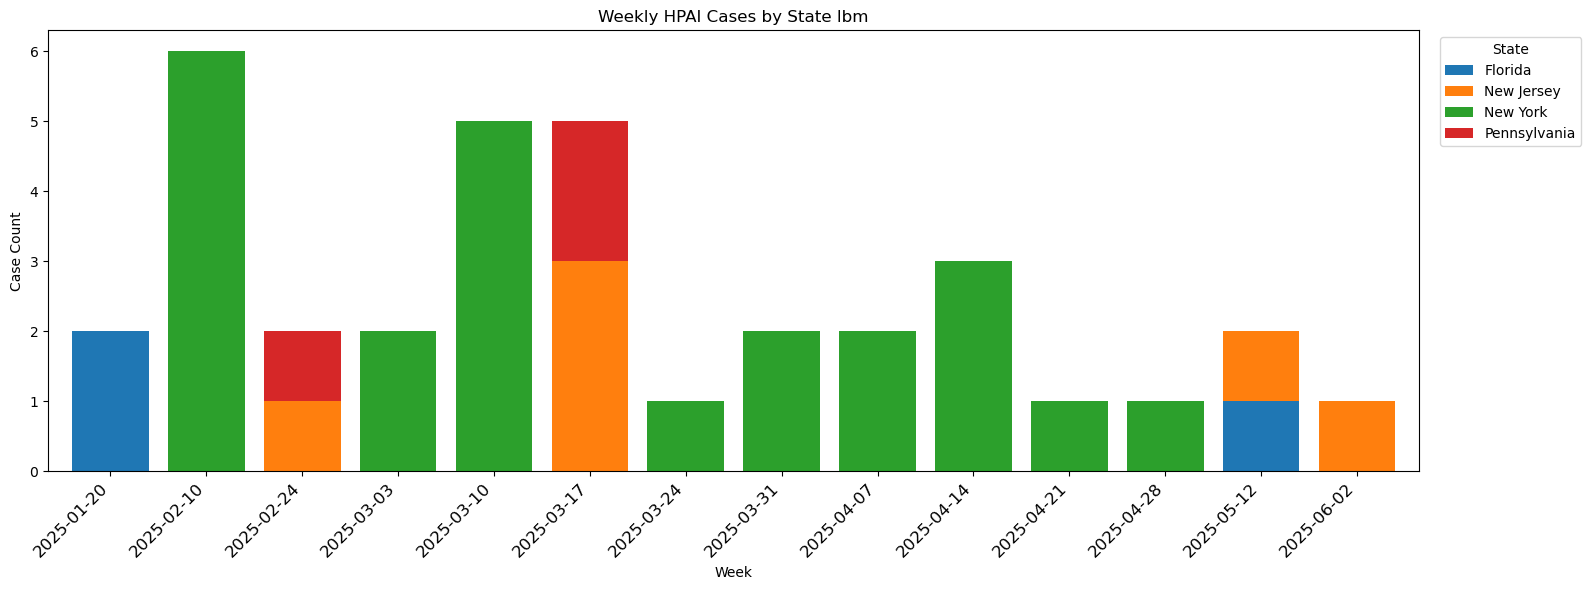

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# Group by state and week
weekly = (
    lbm.groupby(['State', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

# Pivot so each state is a column (needed for stacked bar)
weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='State', values='cases', fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

weekly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8
)

# Convert numeric bar positions back to date labels
week_dates = weekly_pivot.index
ax.set_xticks(range(len(week_dates)))
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in week_dates], rotation=45, ha='right', fontsize=12)

ax.set_xlabel('Week')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State lbm')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_33081/2516202604.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  lbm['state_grouped'] = lbm['State'].map(state_map)


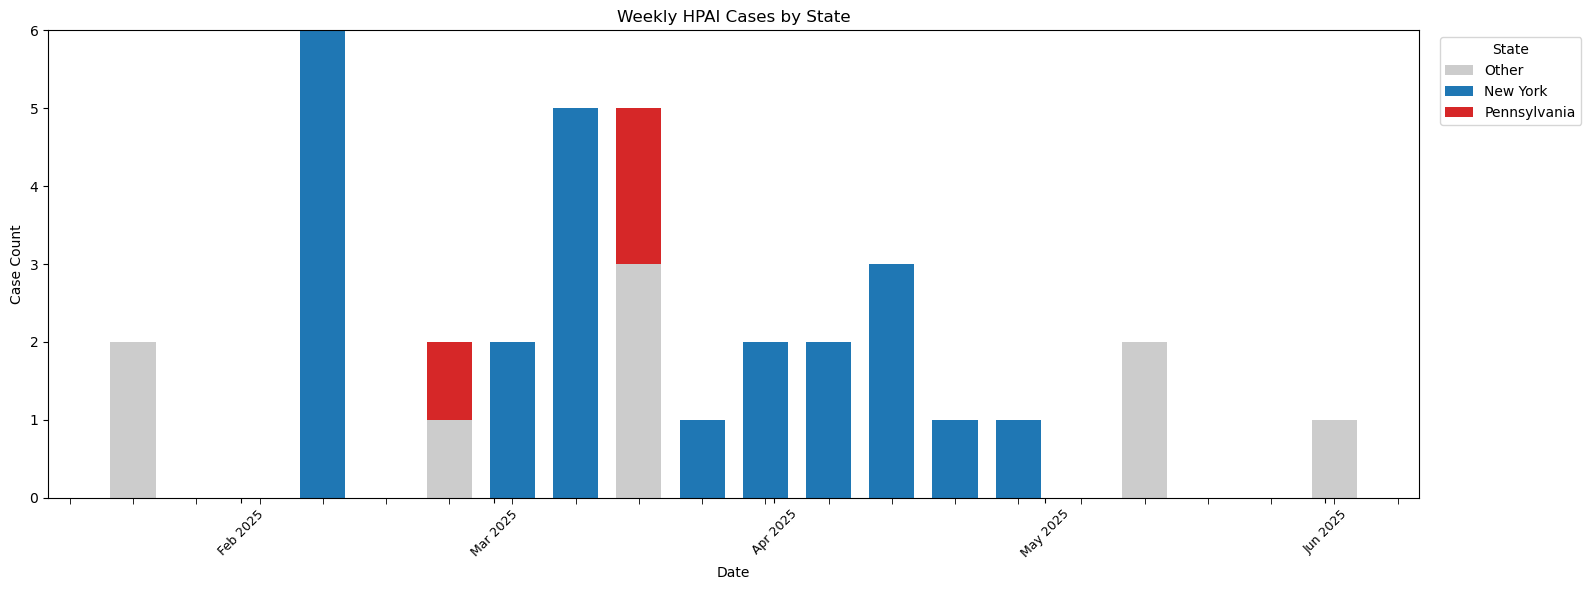

In [37]:
# Remap states to NY, PA, and Other
state_map = {s: s if s in ['New York', 'Pennsylvania'] else 'Other' for s in lbm['State'].unique()}
lbm['state_grouped'] = lbm['State'].map(state_map)

# Group by remapped state and week
weekly = (
    lbm.groupby(['state_grouped', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='state_grouped', values='cases', fill_value=0)

# Ensure consistent column order
col_order = [c for c in ['Other', 'New York', 'Pennsylvania'] if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# --- Plot ---
colors = {'Other': '#cccccc', 'New York': '#1f77b4', 'Pennsylvania': '#d62728'}

fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

for state in col_order:
    ax.bar(x, weekly_pivot[state], width=width,
           bottom=bottoms, label=state, color=colors[state])
    bottoms += weekly_pivot[state].values

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=9, rotation=45)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('Date')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [72]:
com_lbm['Confirmed Diagnosis'] = pd.to_datetime(com_lbm['Confirmed Diagnosis'], format='%d-%b-%y')
com_lbm

,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6
0,Maricopa 04,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-30,17-Jul-25,"1,354,200"
1,Essex 02,Essex,New Jersey,Live Bird Market,2025-05-27,NaN,120
2,Maricopa 03,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-27,23-Jul-25,"1,552,000"
3,Maricopa 02,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-19,29-Jun-25,"2,258,100"
4,Northampton 02,Northampton,Pennsylvania,WOAH Non-Poultry,2025-05-19,NaN,30
...,...,...,...,...,...,...,...
324,Canyon 17,Canyon,Idaho,WOAH Non-Poultry,2025-01-03,NaN,20
325,Pocahontas 01,Pocahontas,West Virginia,WOAH Poultry,2025-01-03,17-Jan-25,9
326,Sharp 01,Sharp,Arkansas,WOAH Non-Poultry,2025-01-03,NaN,20
327,Stanislaus 17,Stanislaus,California,Commercial Broiler Production,2025-01-03,15-Feb-25,"236,100"


In [56]:
com_lbm_ny_pa = com_lbm[(com_lbm['State'] =='New York') | (com_lbm['State'] =='Pennsylvania')]


In [48]:
com = com_lbm[com_lbm['Production'] !='Live Bird Market']
com

,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6,state_grouped
0,Maricopa 04,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-30,17-Jul-25,"1,354,200",NaN
2,Maricopa 03,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-27,23-Jul-25,"1,552,000",NaN
3,Maricopa 02,Maricopa,Arizona,Commercial Table Egg Layer,2025-05-19,29-Jun-25,"2,258,100",NaN
4,Northampton 02,Northampton,Pennsylvania,WOAH Non-Poultry,2025-05-19,NaN,30,Pennsylvania
5,Hutchinson 06,Hutchinson,South Dakota,Commercial Turkey Meat Bird,2025-05-13,30-May-25,"30,900",NaN
...,...,...,...,...,...,...,...,...
324,Canyon 17,Canyon,Idaho,WOAH Non-Poultry,2025-01-03,NaN,20,NaN
325,Pocahontas 01,Pocahontas,West Virginia,WOAH Poultry,2025-01-03,17-Jan-25,9,NaN
326,Sharp 01,Sharp,Arkansas,WOAH Non-Poultry,2025-01-03,NaN,20,NaN
327,Stanislaus 17,Stanislaus,California,Commercial Broiler Production,2025-01-03,15-Feb-25,"236,100",NaN


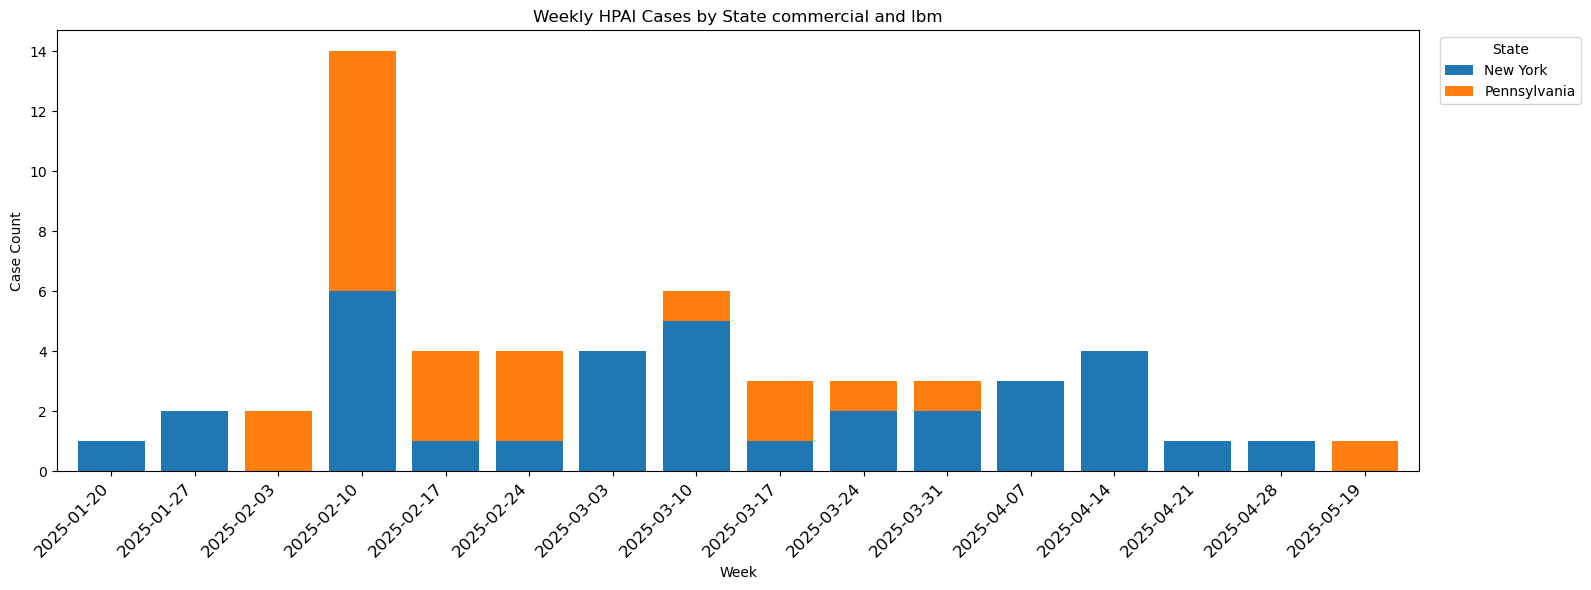

In [51]:
# Group by state and week
weekly = (
    com_lbm_ny_pa.groupby(['State', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

# Pivot so each state is a column (needed for stacked bar)
weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='State', values='cases', fill_value=0)

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

weekly_pivot.plot(
    kind='bar',
    stacked=True,
    ax=ax,
    width=0.8
)

# Convert numeric bar positions back to date labels
week_dates = weekly_pivot.index
ax.set_xticks(range(len(week_dates)))
ax.set_xticklabels([d.strftime('%Y-%m-%d') for d in week_dates], rotation=45, ha='right', fontsize=12)

ax.set_xlabel('Week')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State commercial and lbm')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_33081/1611464549.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com_lbm_ny_pa['group'] = com_lbm_ny_pa['State'] + ' - ' + com_lbm_ny_pa['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')


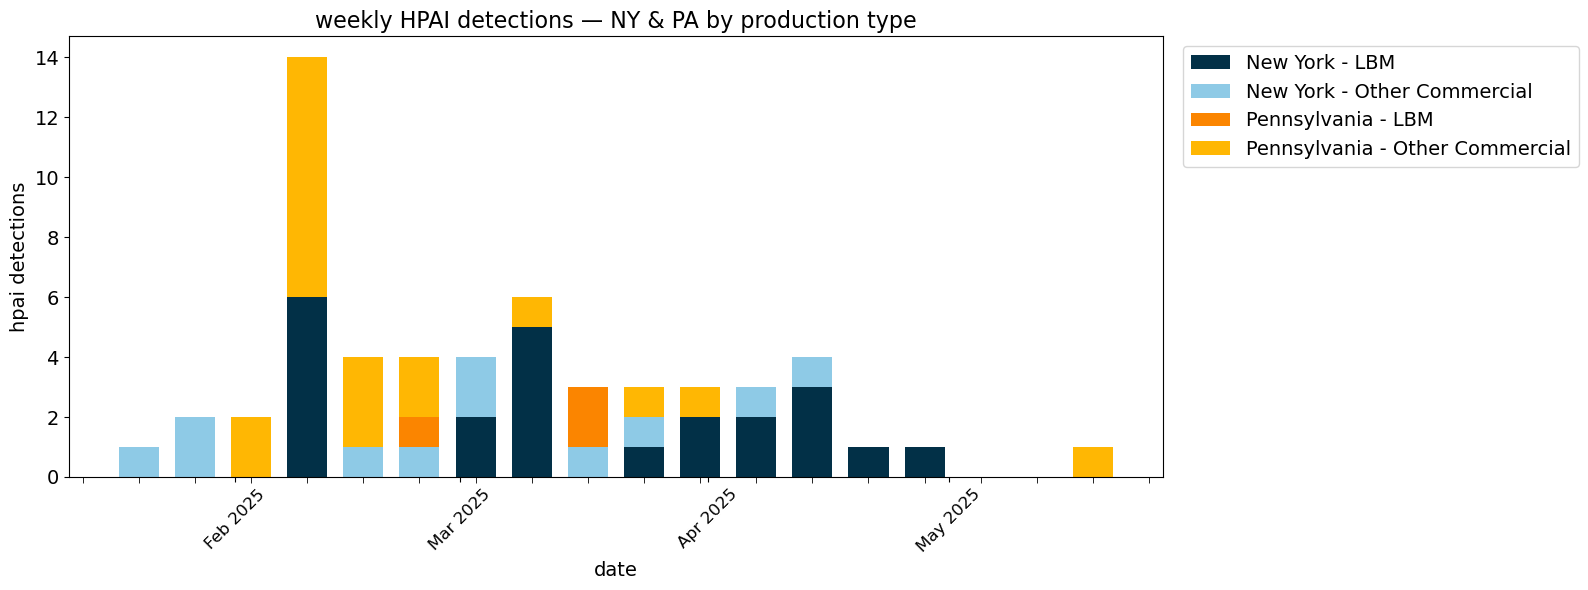

In [66]:
# Create combined grouping column
com_lbm_ny_pa['group'] = com_lbm_ny_pa['State'] + ' - ' + com_lbm_ny_pa['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')

# Group by combined group and week
weekly = (
    com_lbm_ny_pa.groupby(['group', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='group', values='cases', fill_value=0)

# Consistent column order
col_order = [c for c in ['New York - LBM', 'New York - Other Commercial', 
                          'Pennsylvania - LBM', 'Pennsylvania - Other Commercial'] 
             if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# Colors: NY in blues, PA in reds
colors = {
    'New York - LBM':               '#023047',  # dark blue
    'New York - Other Commercial':  '#8ecae6',  # light blue
    'Pennsylvania - LBM':           '#fb8500',  # dark red
    'Pennsylvania - Other Commercial': '#ffb703', # light red
}

# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

for group in col_order:
    ax.bar(x, weekly_pivot[group], width=width,
           bottom=bottoms, label=group, color=colors[group])
    bottoms += weekly_pivot[group].values

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=12, rotation=45)
ax.tick_params(axis='y', which='major', labelsize=14)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('date', fontsize=14)
ax.set_ylabel('hpai detections' , fontsize=14)
ax.set_title('weekly HPAI detections — NY & PA by production type', fontsize=16)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=14)

plt.tight_layout()
plt.savefig('../beast_d11_dta/lbm-com-ny-pa-detections.png', format='png')
plt.show()

In [73]:
com_lbm_ny_pa_nj = com_lbm[(com_lbm['State'] =='New York') | (com_lbm['State'] =='Pennsylvania') | (com_lbm['State'] =='New Jersey')]
com_lbm_ny_pa_nj

,Special ID,County Name,State,Production,Confirmed Diagnosis,Control Area Released,Unnamed: 6
1,Essex 02,Essex,New Jersey,Live Bird Market,2025-05-27,NaN,120
4,Northampton 02,Northampton,Pennsylvania,WOAH Non-Poultry,2025-05-19,NaN,30
6,Essex 01,Essex,New Jersey,Live Bird Market,2025-05-12,NaN,"1,400"
13,Queens 18,Queens,New York,Live Bird Market,2025-04-24,NaN,0
16,Queens 17,Queens,New York,Live Bird Market,2025-04-18,NaN,930
...,...,...,...,...,...,...,...
223,Lehigh 07,Lehigh,Pennsylvania,WOAH Poultry,2025-01-28,15-Feb-25,"48,000"
236,Ulster 02,Ulster,New York,WOAH Non-Poultry,2025-01-27,NaN,60
259,Putnam 03,Putnam,New York,WOAH Non-Poultry,2025-01-23,NaN,60
277,Suffolk 05,Suffolk,New York,Commercial Duck Meat Bird,2025-01-17,19-Mar-25,"101,000"


In [83]:
com_lbm_ny_pa_nj['Production'].unique()

array(['Live Bird Market', 'WOAH Non-Poultry', 'WOAH Poultry',
       'Commercial Turkey Meat Bird', 'Commercial Duck Meat Bird',
       'Commercial Broiler Production', 'Commercial Table Egg Layer'],
      dtype=object)

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_91387/4056493877.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com_lbm_ny_pa_nj['group'] = com_lbm_ny_pa_nj['State'] + ' - ' + com_lbm_ny_pa_nj['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')


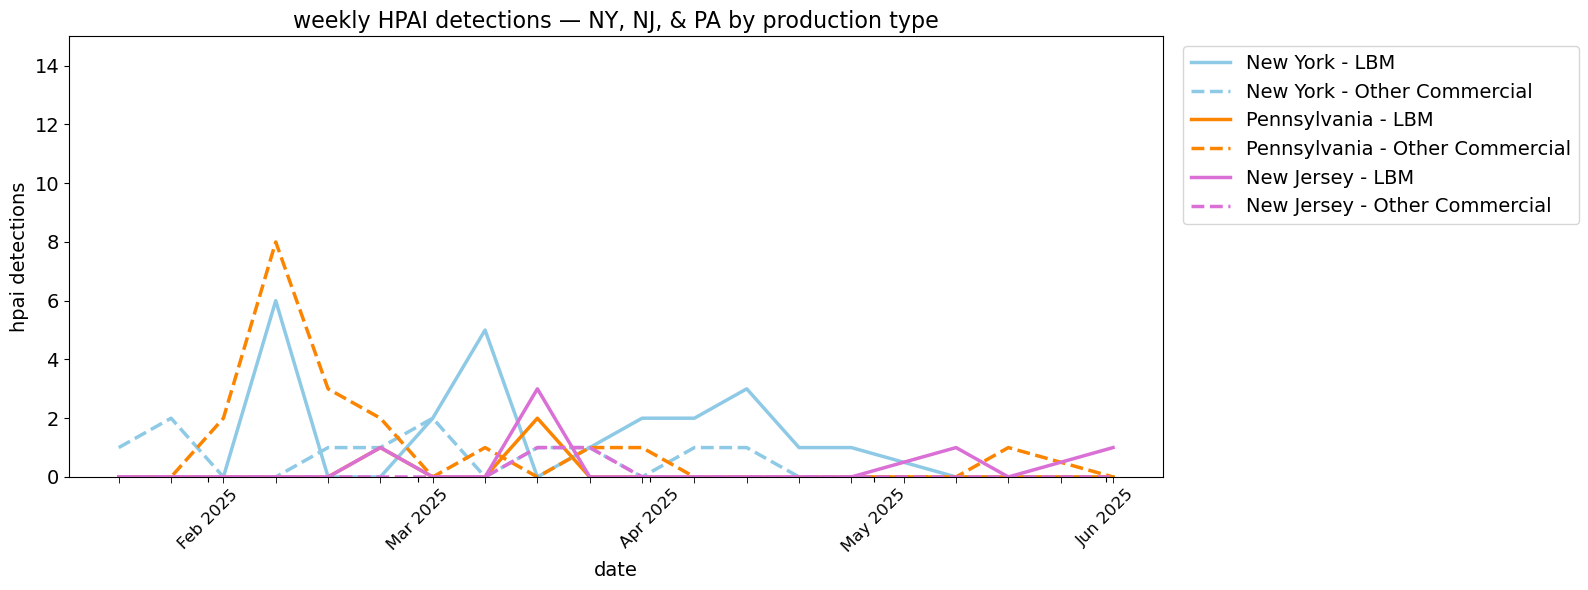

In [66]:
# Create combined grouping column
com_lbm_ny_pa_nj['group'] = com_lbm_ny_pa_nj['State'] + ' - ' + com_lbm_ny_pa_nj['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')

# Group by combined group and week
weekly = (
    com_lbm_ny_pa_nj.groupby(['group', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='group', values='cases', fill_value=0)

# Consistent column order
col_order = [c for c in ['New York - LBM', 'New York - Other Commercial', 
                          'Pennsylvania - LBM', 'Pennsylvania - Other Commercial',
                         'New Jersey - LBM', 'New Jersey - Other Commercial'] 
             if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# Colors: NY in blues, PA in reds
colors = {
    'New York - LBM':               '#8ecae6',  # light blue
    'New York - Other Commercial':  '#8ecae6',  # light blue
    'Pennsylvania - LBM':           '#fb8500',  # orange
    'Pennsylvania - Other Commercial': '#fb8500', # orange
    'New Jersey - LBM':             '#DA70D6', #pink purple
    'New Jersey - Other Commercial':  '#DA70D6' #pink purple
} 


linestyles = {
    'New York - LBM':                  '-',
    'New York - Other Commercial':     '--',
    'Pennsylvania - LBM':              '-',
    'Pennsylvania - Other Commercial': '--',
    'New Jersey - LBM':                '-',
    'New Jersey - Other Commercial':   '--'
}


# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

# for group in col_order:
#     ax.bar(x, weekly_pivot[group], width=width,
#            bottom=bottoms, label=group, color=colors[group])
#     bottoms += weekly_pivot[group].values

for group in col_order:
    ax.plot(x, weekly_pivot[group], label=group,
            color=colors[group], linestyle=linestyles[group], linewidth=2.5)


ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=12, rotation=45)
ax.tick_params(axis='y', which='major', labelsize=14)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('date', fontsize=14)
ax.set_ylabel('hpai detections' , fontsize=14)
plt.ylim(0, 15)
ax.set_title('weekly HPAI detections — NY, NJ, & PA by production type', fontsize=16)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=14)

plt.tight_layout()
# plt.savefig('../beast_d11_dta/lbm-com-ny-nj0 pa-detections.png', format='png')
plt.show()

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_91387/829480130.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com_lbm_ny_pa_nj['group'] = com_lbm_ny_pa_nj['State'] + ' - ' + com_lbm_ny_pa_nj['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')


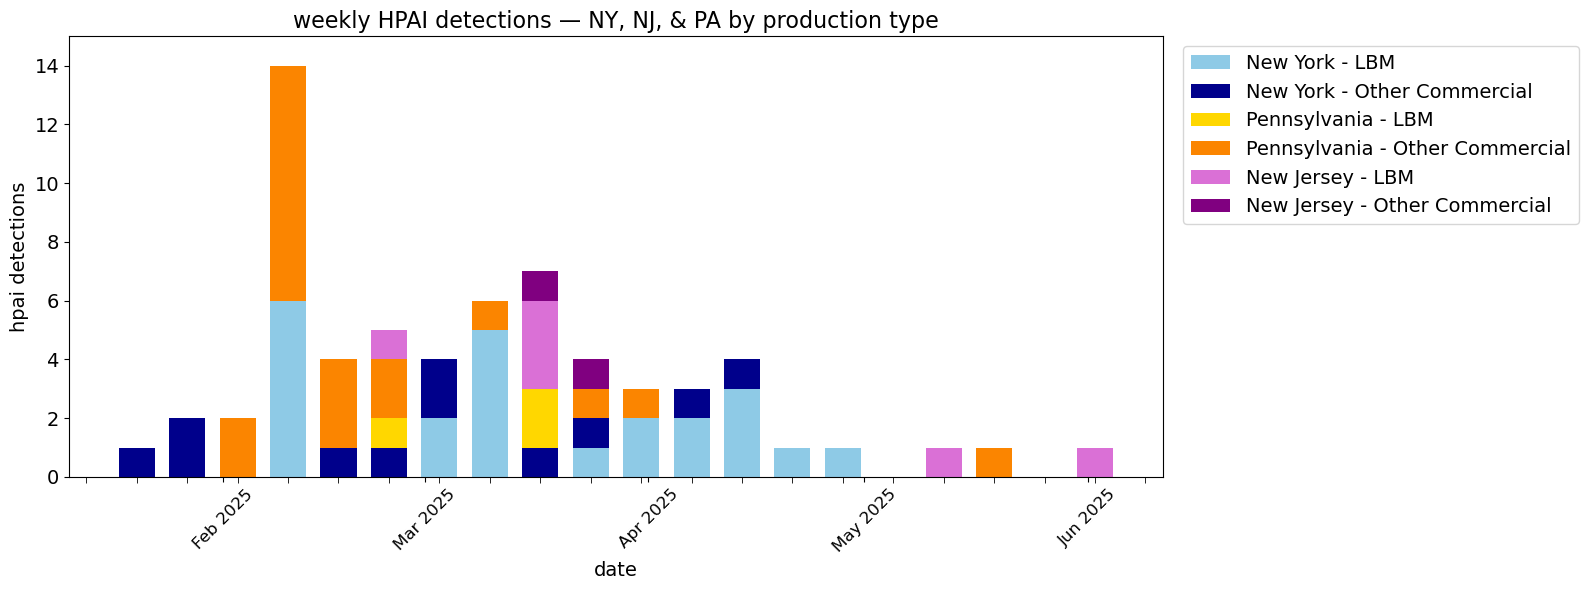

In [64]:
# Create combined grouping column
com_lbm_ny_pa_nj['group'] = com_lbm_ny_pa_nj['State'] + ' - ' + com_lbm_ny_pa_nj['Production'].apply(lambda x: 'LBM' if x == 'Live Bird Market' else 'Other Commercial')

# Group by combined group and week
weekly = (
    com_lbm_ny_pa_nj.groupby(['group', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='group', values='cases', fill_value=0)

# Consistent column order
col_order = [c for c in ['New York - LBM', 'New York - Other Commercial', 
                          'Pennsylvania - LBM', 'Pennsylvania - Other Commercial',
                         'New Jersey - LBM', 'New Jersey - Other Commercial'] 
             if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# Colors: NY in blues, PA in reds
colors = {
    'New York - LBM':               '#8ecae6',  # light blue
    'New York - Other Commercial':  'darkblue',  # dark blue
    'Pennsylvania - LBM':           'gold',  # gold
    'Pennsylvania - Other Commercial': '#fb8500', # orange
    'New Jersey - LBM':             '#DA70D6', #pink purple
    'New Jersey - Other Commercial':  'purple' # purple
} 


# linestyles = {
#     'New York - LBM':                  '-',
#     'New York - Other Commercial':     '--',
#     'Pennsylvania - LBM':              '-',
#     'Pennsylvania - Other Commercial': '--',
#     'New Jersey - LBM':                '-',
#     'New Jersey - Other Commercial':   '--'
# }


# --- Plot ---
fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

for group in col_order:
    ax.bar(x, weekly_pivot[group], width=width,
           bottom=bottoms, label=group, color=colors[group])
    bottoms += weekly_pivot[group].values



ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=12, rotation=45)
ax.tick_params(axis='y', which='major', labelsize=14)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('date', fontsize=14)
ax.set_ylabel('hpai detections' , fontsize=14)
plt.ylim(0, 15)
ax.set_title('weekly HPAI detections — NY, NJ, & PA by production type', fontsize=16)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=14)

plt.tight_layout()
# plt.savefig('../beast_d11_dta/lbm-com-ny-nj0 pa-detections.png', format='png')
plt.show()

In [90]:
com_lbm_ny_pa_nj.to_csv('../comm-pa/output_dfs/com_lbm_pa_nj_case_cts.tsv', sep='\t')

/var/folders/8h/zkgpnzwj7f9d82wldp_d4h_w0000gs/T/ipykernel_33081/137581322.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  com['state_grouped'] = com['State'].map(state_map)


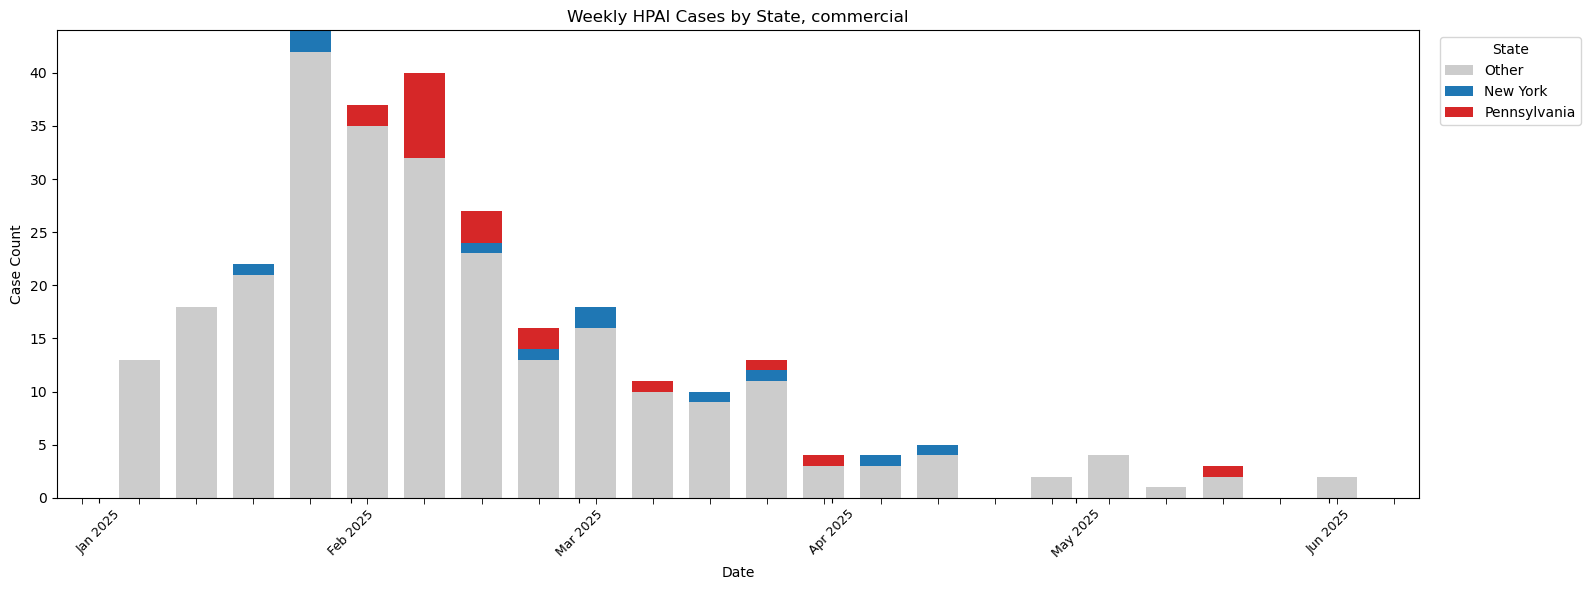

In [49]:
# Remap states to NY, PA, and Other
state_map = {s: s if s in ['New York', 'Pennsylvania'] else 'Other' for s in com['State'].unique()}
com['state_grouped'] = com['State'].map(state_map)

# Group by remapped state and week
weekly = (
    com.groupby(['state_grouped', pd.Grouper(key='Confirmed Diagnosis', freq='W-MON')])
    .size()
    .reset_index(name='cases')
)

weekly_pivot = weekly.pivot_table(index='Confirmed Diagnosis', columns='state_grouped', values='cases', fill_value=0)

# Ensure consistent column order
col_order = [c for c in ['Other', 'New York', 'Pennsylvania'] if c in weekly_pivot.columns]
weekly_pivot = weekly_pivot[col_order]

# --- Plot ---
colors = {'Other': '#cccccc', 'New York': '#1f77b4', 'Pennsylvania': '#d62728'}

fig, ax = plt.subplots(figsize=(16, 6))

week_dates = weekly_pivot.index
x = mdates.date2num(week_dates.to_pydatetime())
width = 5
bottoms = np.zeros(len(week_dates))

for state in col_order:
    ax.bar(x, weekly_pivot[state], width=width,
           bottom=bottoms, label=state, color=colors[state])
    bottoms += weekly_pivot[state].values

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.tick_params(axis='x', which='major', labelsize=9, rotation=45)
ax.tick_params(axis='x', which='minor', length=4)

ax.set_xlabel('Date')
ax.set_ylabel('Case Count')
ax.set_title('Weekly HPAI Cases by State, commercial')
ax.legend(title='State', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()